# 🎓 Học Phần: Phân Tích Cốt Lõi Tín Hiệu Âm Thanh

Chào bạn! Để nắm bắt cách thức vận hành của âm thanh kỹ thuật số, chúng ta sẽ chia nhỏ quy trình thành các bước logic. Mỗi bước sẽ được đóng gói trong một hàm riêng biệt để bạn dễ dàng quan sát "đầu vào" và "đầu ra".

In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

print("🚀 Đã sẵn sàng!")

🚀 Đã sẵn sàng!


--- 
## 🛑 Bước 1: Tải và Giải mã Âm thanh (Loading & Decoding)

### Mô tả hàm:
Hàm này chuyển đổi một file âm thanh (định dạng nén như .mp3, .wav) thành một **chuỗi số thực** mà máy tính có thể tính toán được.

### Đầu ra là gì?:
- **`y` (Tín hiệu)**: Một mảng NumPy (1 chiều) chứa các giá trị biên độ của sóng âm.
- **`sr` (Tần số lấy mẫu)**: Số lượng mẫu được ghi lại trong 1 giây (đơn vị Hz).

### Ý nghĩa & Công thức:
- **Công thức**: $T = \frac{1}{sr}$ (Thời gian giữa 2 mẫu liên tiếp).
- **Ý nghĩa**: Âm thanh được "chụp ảnh" lại hàng chục nghìn lần mỗi giây. Nếu $sr = 22050$, nghĩa là mỗi giây có 22,050 điểm dữ liệu.

### Mục đích:
Biến âm thanh từ dạng sóng vật lý thành dữ liệu số (Digital Data) để xử lý toán học.

In [6]:
def buoc_1_tai_audio(path=None):
    # Nếu không nhập path, dùng file mẫu 'choice' (tiếng người nói)
    if not path:
        path = librosa.ex('choice')
        
    # Load audio
    y, sr = librosa.load(path)
    
    print("--- KẾT QUẢ BƯỚC 1 ---")
    print(f"Mảng tín hiệu (y) 50 giá trị đầu: {y[:50]}")
    print(f"Tần số lấy mẫu (sr): {sr} Hz")
    print(f"Tổng số điểm dữ liệu: {len(y)}")
    return y, sr

# Chạy thử
y, sr = buoc_1_tai_audio(r"C:\Users\Admin\Desktop\SLP301\practice_analysis\Speaker0040_000.wav")

--- KẾT QUẢ BƯỚC 1 ---
Mảng tín hiệu (y) 50 giá trị đầu: [ 0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  0.0000000e+00  0.0000000e+00
  0.0000000e+00  0.0000000e+00  3.0517578e-05 -6.1035156e-05
  6.1035156e-05 -6.1035156e-05  6.1035156e-05 -3.0517578e-05
  0.0000000e+00  3.0517578e-05 -6.1035156e-05  3.0517578e-05
  3.0517578e-05 -6.1035156e-05  6.1035156e-05 -3.0517578e-05
  0.0000000e+00  3.0517578e-05 -3.0517578e-05  0.0000000e+00
  3.0517578e-05 -6.1035156e-05  6.1035156e-05 -3.0517578e-05
  0.0000000e+00  3.0517578e-05 -6.1035156e-05  3.0517578e-05
  0.0000000e+00  0.0000000e+00  3.0517578e-05 -6.1035156e-05
  3.0517578e-05  0.0000000e+00  0.0000000e+00  3.0517578e-05
 -6.1035156e-05  6.1035156e-05 -6.1035156e-05  6.1035156e-05
 -3.0517578e-05  0.0000000e+00]
Tần số lấy mẫu (sr): 22050 Hz
Tổng số điểm dữ liệu: 1323008


--- 
## 📉 Bước 2: Hiển thị Dạng sóng (Waveform)

### Mô tả hàm:
Vẽ biểu đồ biểu diễn biên độ âm thanh thay đổi như thế nào theo thời gian.

### Đầu ra là gì?:
- Một biểu đồ đường (Time-Domain Plot).

### Ý nghĩa:
- **Trục ngang (X)**: Thời gian (giây).
- **Trục dọc (Y)**: Biên độ (Amplitude). Giá trị càng xa mức 0 thì âm thanh càng to.

### Mục đích:
Giúp ta quan sát trực quan độ to/nhỏ của file âm thanh theo thời gian thực.

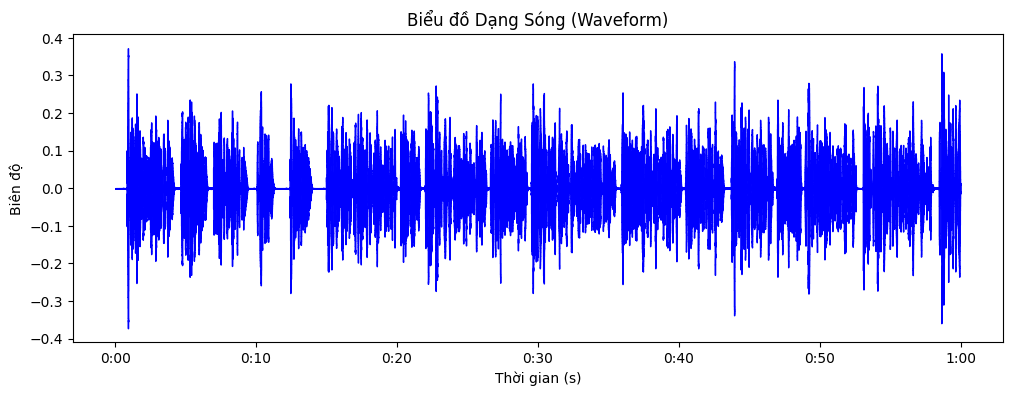

--- KẾT QUẢ BƯỚC 2 ---
Đã hiển thị biểu đồ thời gian.


In [7]:
def buoc_2_ve_waveform(y, sr):
    plt.figure(figsize=(12, 4))
    # Hàm display.waveshow giúp vẽ dạng sóng cực nhanh
    librosa.display.waveshow(y, sr=sr, color="blue")
    
    plt.title("Biểu đồ Dạng Sóng (Waveform)")
    plt.xlabel("Thời gian (s)")
    plt.ylabel("Biên độ")
    plt.show()
    print("--- KẾT QUẢ BƯỚC 2 ---")
    print("Đã hiển thị biểu đồ thời gian.")

buoc_2_ve_waveform(y, sr)

--- 
## ⚡ Bước 3: Biến đổi Fourier (STFT - Chuyển sang miền Tần số)

### Mô tả hàm:
Sử dụng thuật toán **STFT (Short-Time Fourier Transform)** để chia nhỏ âm thanh và xem bên trong nó có những tần số nào.

### Đầu ra là gì?:
- **`D`**: Một ma trận số phức (Complex numbers).

### Ý nghĩa & Công thức:
- **Công thức**: $X(t, f) = \int w(t-\tau)x(\tau)e^{-j2\pi f \tau} d\tau$ (Tích phân Fourier trên cửa sổ trượt).
- **Giải thích dễ hiểu**: Bạn đang "soi" âm thanh qua lăng kính để tách các màu sắc (tần số). Một nốt nhạc to sẽ tương ứng với một giá trị số lớn trong ma trận này.

### Mục đích:
Tìm ra thành phần tần số (cao/thấp) ẩn giấu trong sóng âm.

In [8]:
def buoc_3_bien_doi_fourier(y):
    # n_fft=2048: Kích thước cửa sổ phân tích
    D = librosa.stft(y)
    
    print("--- KẾT QUẢ BƯỚC 3 ---")
    print(f"Kích thước ma trận Fourier (Tần số x Thời gian): {D.shape}")
    print(f"Ví dụ 1 giá trị số phức tại [0,0]: {D[0,0]}")
    return D

D = buoc_3_bien_doi_fourier(y)

--- KẾT QUẢ BƯỚC 3 ---
Kích thước ma trận Fourier (Tần số x Thời gian): (1025, 2585)
Ví dụ 1 giá trị số phức tại [0,0]: (1.8332719264435582e-05+0j)


--- 
## 📏 Bước 4: Chuyển sang Decibel (dB - Thang đo tai người)

### Mô tả hàm:
Tai người không nghe âm thanh theo kiểu tuyến tính (gấp đôi biên độ không có nghĩa là thấy to gấp đôi). Chúng ta nghe theo thang Logarit (Decibel).

### Đầu ra là gì?:
- **`S_db`**: Ma trận các số thực biểu diễn cường độ âm thanh theo đơn vị dB.

### Ý nghĩa & Công thức:
- **Công thức**: $dB = 20 \cdot \log_{10}(|Amplitude|)$
- **Ý nghĩa**: Giá trị 0 dB là mức to nhất trong file. Các giá trị âm (ví dụ -20dB, -40dB) biểu thị âm thanh nhỏ dần.

### Mục đích:
Chuẩn hóa dữ liệu về định dạng mà con người có thể cảm nhận và phân tích được trên biểu đồ.

In [9]:
def buoc_4_chuyen_sang_db(D):
    # np.abs(D) lấy biên độ (bỏ phần ảo của số phức)
    # amplitude_to_db chuyển sang thang Logarit
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    print("--- KẾT QUẢ BƯỚC 4 ---")
    print(f"Giá trị dB lớn nhất: {np.max(S_db)} dB")
    print(f"Giá trị dB nhỏ nhất: {np.min(S_db)} dB")
    return S_db

S_db = buoc_4_chuyen_sang_db(D)

--- KẾT QUẢ BƯỚC 4 ---
Giá trị dB lớn nhất: 0.0 dB
Giá trị dB nhỏ nhất: -80.0 dB


--- 
## 🌈 Bước 5: Hiển thị Spectrogram (Ảnh phổ)

### Mô tả hàm:
Tổng hợp tất cả dữ liệu từ Bước 4 lên một bản đồ nhiệt (Heatmap).

### Đầu ra là gì?:
- Biểu đồ đa sắc màu.

### Ý nghĩa:
- **Trục X**: Thời gian.
- **Trục Y**: Tần số (Hz).
- **Màu sắc**: Độ to (Càng sáng = Càng to).

### Mục đích:
Nhìn thấy toàn cảnh bức tranh âm thanh: Khi nào có tiếng nói, khi nào im lặng, giọng nói đó trầm hay bổng.

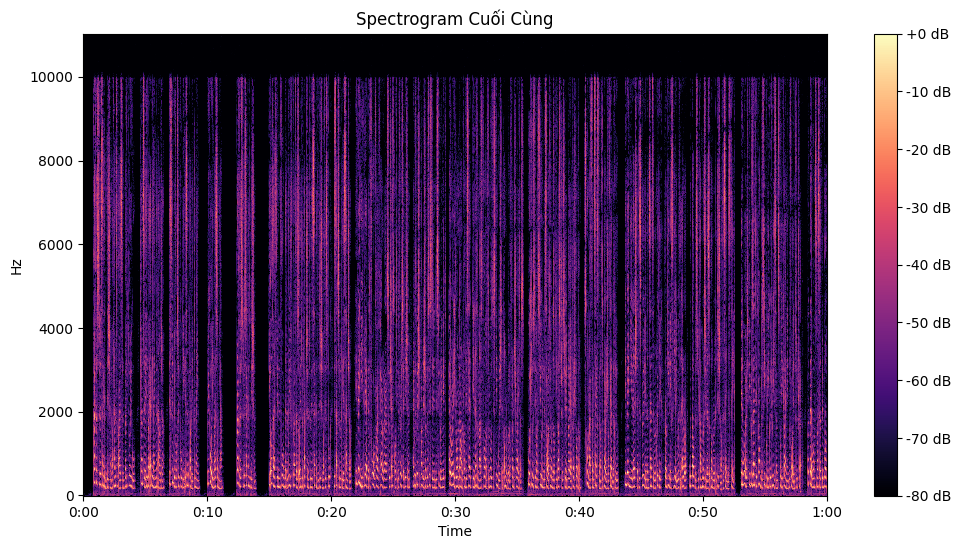

--- HOÀN THÀNH ---
Bạn đã có bức tranh toàn cảnh về file âm thanh!


In [10]:
def buoc_5_ve_spectrogram(S_db, sr):
    plt.figure(figsize=(12, 6))
    # Dùng y_axis='hz' để hiển thị tần số theo Hz
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
    
    plt.colorbar(img, format='%+2.0f dB')
    plt.title("Spectrogram Cuối Cùng")
    plt.show()
    print("--- HOÀN THÀNH ---")
    print("Bạn đã có bức tranh toàn cảnh về file âm thanh!")

buoc_5_ve_spectrogram(S_db, sr)